---

digital brain MEG pipeline

---

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# load pgl actions
from pgl import pglActions

---

load session

---

In [ ]:

# Load the session
#loadSession = pglActions.loadSession()
#loadSession.configure()
#if loadSession: session = loadSession.run()

---

Load FieldLine data

---

In [2]:
# configure the load
loadFieldline = pglActions.loadFieldline()
loadFieldline.configure(dataPath='/Users/justin/Desktop/digitalbrain')


In [3]:
# and run it
newSession=loadFieldline.run()
if newSession: session = newSession

(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0002/2026-09-09/20260909_122812_sub-S002_file-ThingsPilotRun01_raw.fif


---

Concatenate raws

---

In [4]:
# configure the concatenation
mneConcatenate = pglActions.mneConcatenate()
mneConcatenate.configure(session, all=True)

In [5]:
# run the concatenation
newSession = mneConcatenate.run(session)
if newSession: session = newSession

(mneConcatenate:_run) Set bads for concatenation to: {'L605_bz-s90', 'L308_bz-s74', 'L504_bz-s86', 'L117_bz-s113'}


---

Set names of events

---

In [6]:
# configure the concatenation
mneConfigureEvents = pglActions.mneConfigureEvents()

# group all the things labels into one
grouped = {
    'things': range(2,201),
    'blank': 1022,
    'catch': 1023
}

# label each stimulus with its own name
each = {
    f"stimulus {code:03d}": code
    for code in range(2, 201)
}
each["blank"] = 1022
each["catch"] = 1023

triggerLabelSets = {
    "grouped": grouped,
    "each": each
}

# configure
mneConfigureEvents.configure(triggerChannel='di2', triggerShortestEvent=1, triggerLabelSets = triggerLabelSets)

Finding events on: di2
1610 events found on stim channel di2
Event IDs: [   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  165  166  167  168  169
  170  171  172  173  174  175  176  177  178  179  180  181  182  183
  184

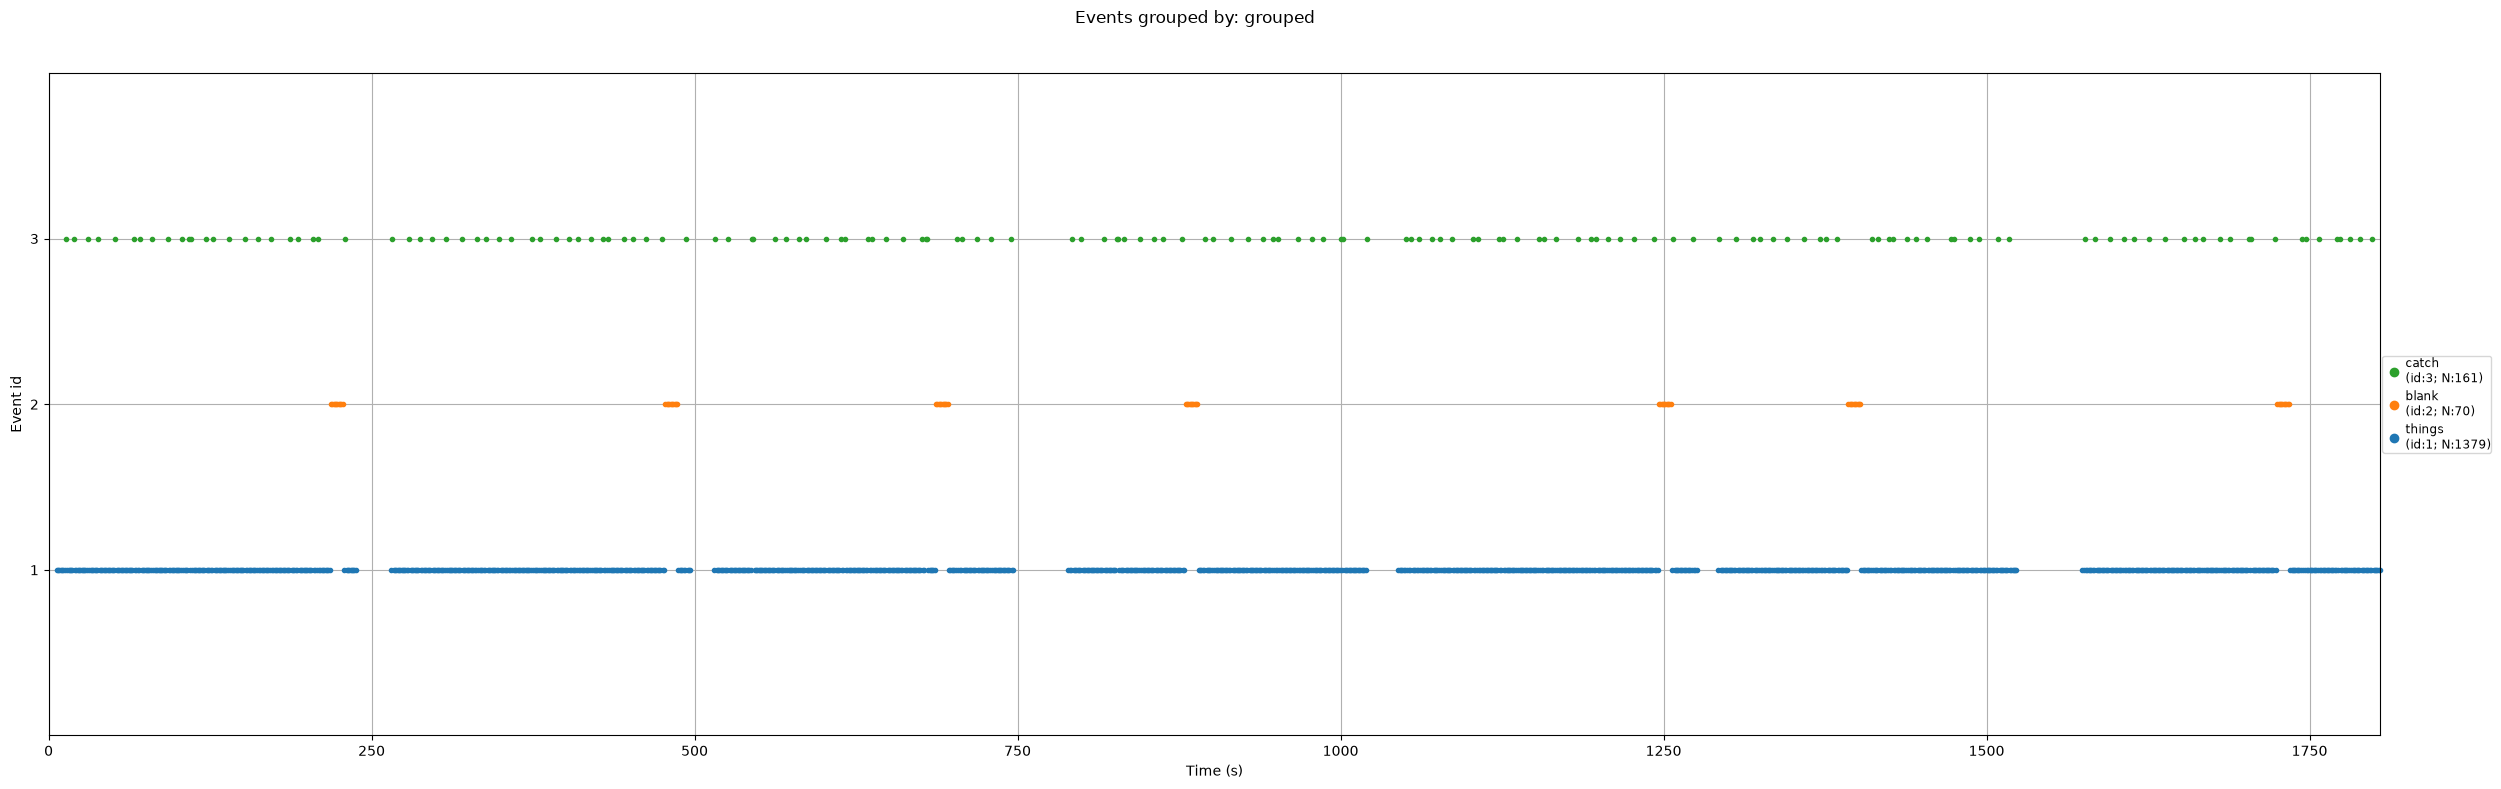

In [7]:
# configure the events
newSession = mneConfigureEvents.run(session)
if newSession: session = newSession

---

Filter data

---

In [8]:
mneFilter = pglActions.mneFilter()
mneFilter.configure(lowCutoff=1.0, highCutoff=40.0, notch=True, notchFrequency=60.0)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 331 samples (0.331 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter

/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


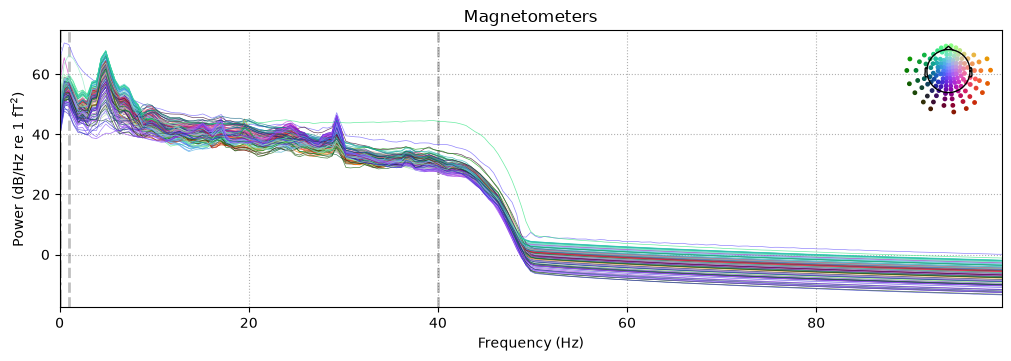

In [9]:
newSession = mneFilter.run(session)
if newSession: session = newSession

---

Bads handling

---

In [10]:
mneBads = pglActions.mneBads()
mneBads.configure(excludeWhenPositionIsNaN=True, extraBads=[], interpolationOrigin="zero", method="interpolate")

In [11]:
newSession = mneBads.run(session)
if newSession: session = newSession

+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
(mneBads:_run) Interpolating 4 bad sesnsors: ['L605_bz-s90', 'L308_bz-s74', 'L504_bz-s86', 'L117_bz-s113']
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
Setting channel interpolation method to {'meg': 'MNE'}.
Interpolating bad channels.
    Computing dot products for 137 MEG channels...
    Computing cross products for 137 → 4 MEG channels...
    Preparing the mapping matrix...
    Truncating at 100/137 components to omit less than 0.0001 (9.9e-05)


---

create epochs

---

In [12]:
mneCreateEpochs = pglActions.mneCreateEpochs()
mneCreateEpochs.configure(tmin=0.0, tmax=1.0)

In [16]:
newSession = mneCreateEpochs.run(session)
if newSession: session = newSession

---

Plot evoked

---

In [17]:
mnePlotEvoked = pglActions.mnePlotEvoked()
mnePlotEvoked.configure(set="grouped",label="things")
#mnePlotEvoked.configure(set="each",label="stimulus 150")

No projector specified for this dataset. Please consider the method self.add_proj.


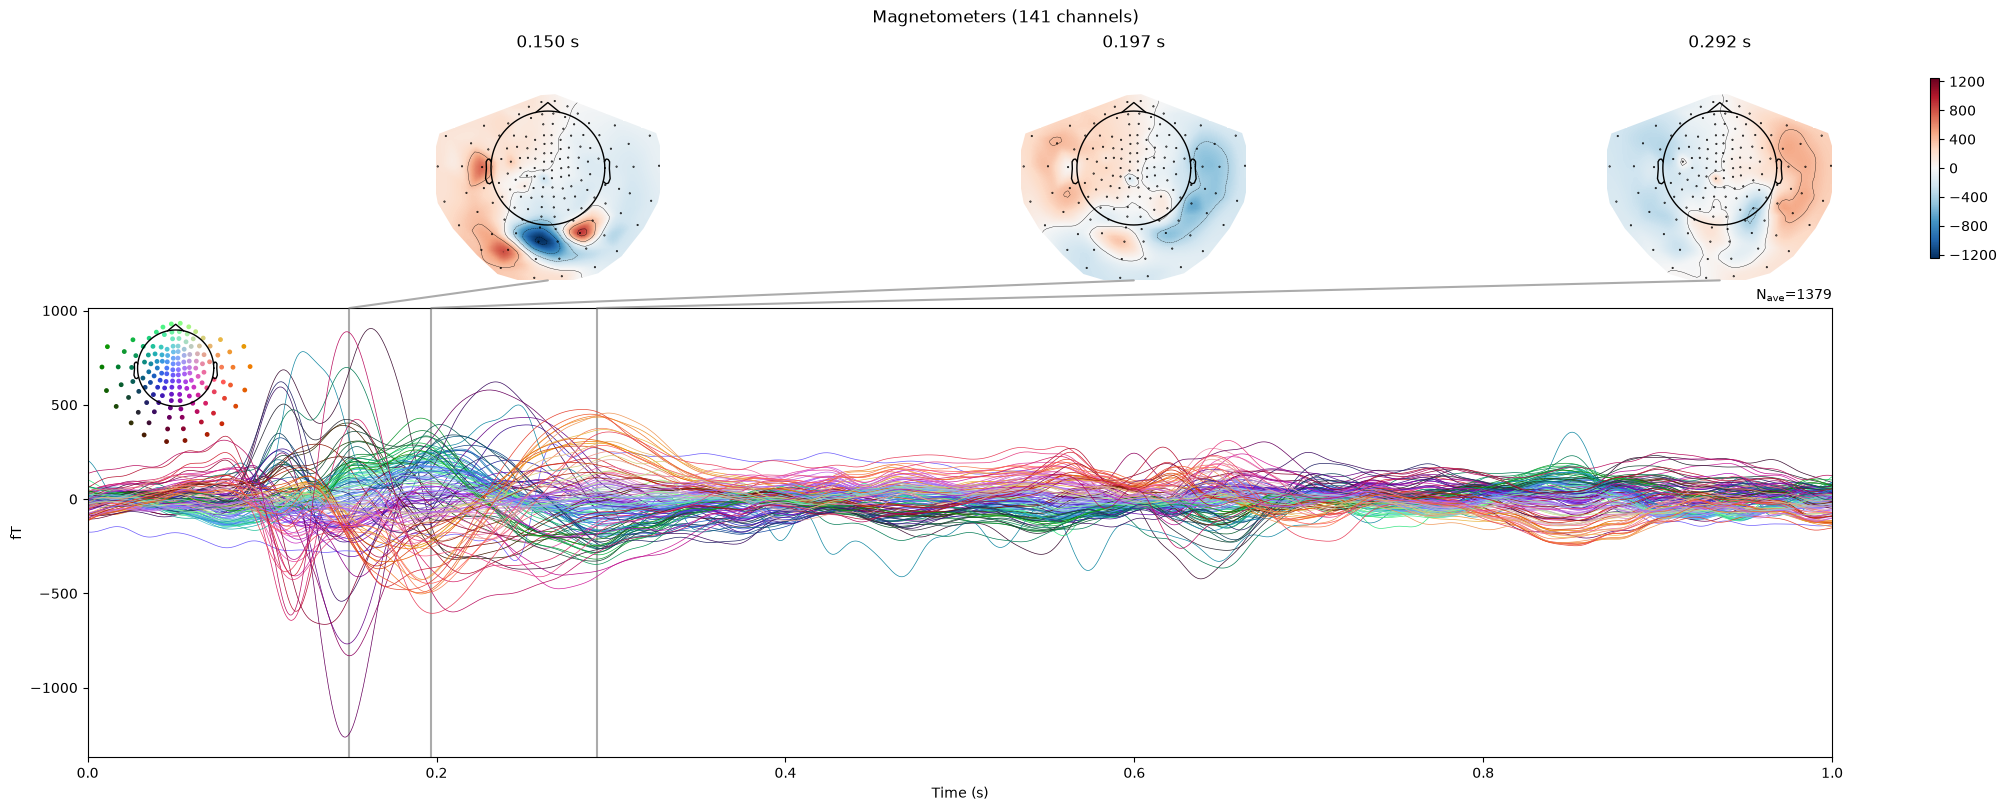

In [19]:
newSession = mnePlotEvoked.run(session)
if newSession: session = newSession